## Importing Files


In [39]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()


## Checking the Data

## Importing Files


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()


## Checking the Data

In [ ]:

raw_data = pd.read_csv('WineQT.csv')
raw_data.isnull().sum()




fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

## Visualizing the Data

In [ ]:
raw_data.describe(include='all')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


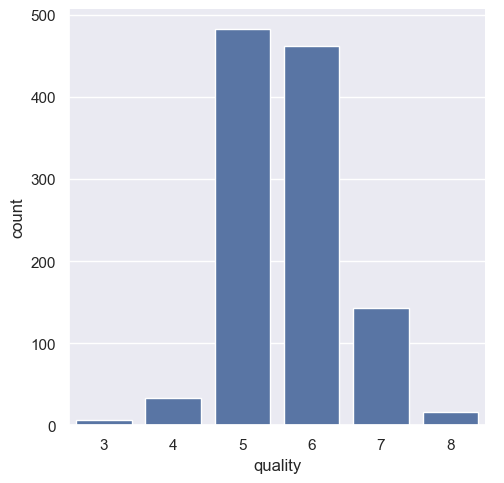

In [ ]:
sns.catplot(x='quality',data=raw_data,kind='count')

<Axes: xlabel='quality', ylabel='volatile acidity'>

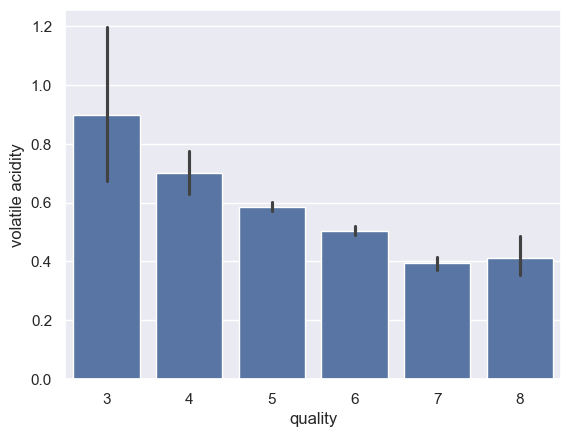

In [ ]:
sns.barplot(x='quality',y='volatile acidity',data=raw_data)

From this we know that, as volatile acidity decreases, the quality increases

<Axes: xlabel='quality', ylabel='citric acid'>

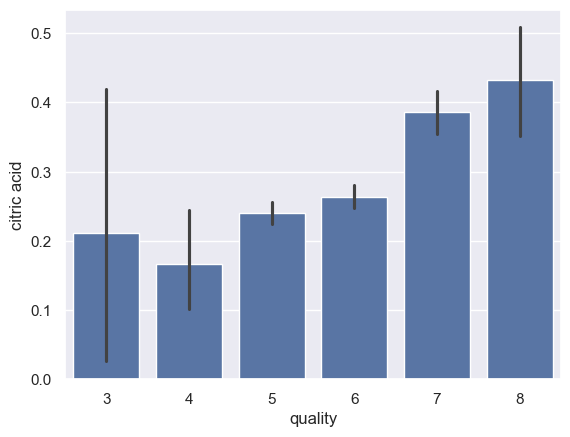

In [ ]:
sns.barplot(x='quality',y='citric acid',data=raw_data)

From this we can conclude that as citric acid value increases, the quality increases


## Splitting Features

In [ ]:
x = raw_data.drop(columns='quality')
y = raw_data['quality']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)



(914,)

## Balancing the Data using SMOTE:

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

## Training and Building the Model


In [ ]:
model = RandomForestClassifier()
model.fit(x_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Predicting the test data


In [ ]:
yhat = model.predict(x_test)



## Checking which feature matters:


<Axes: xlabel='feature_name', ylabel='feature_value'>

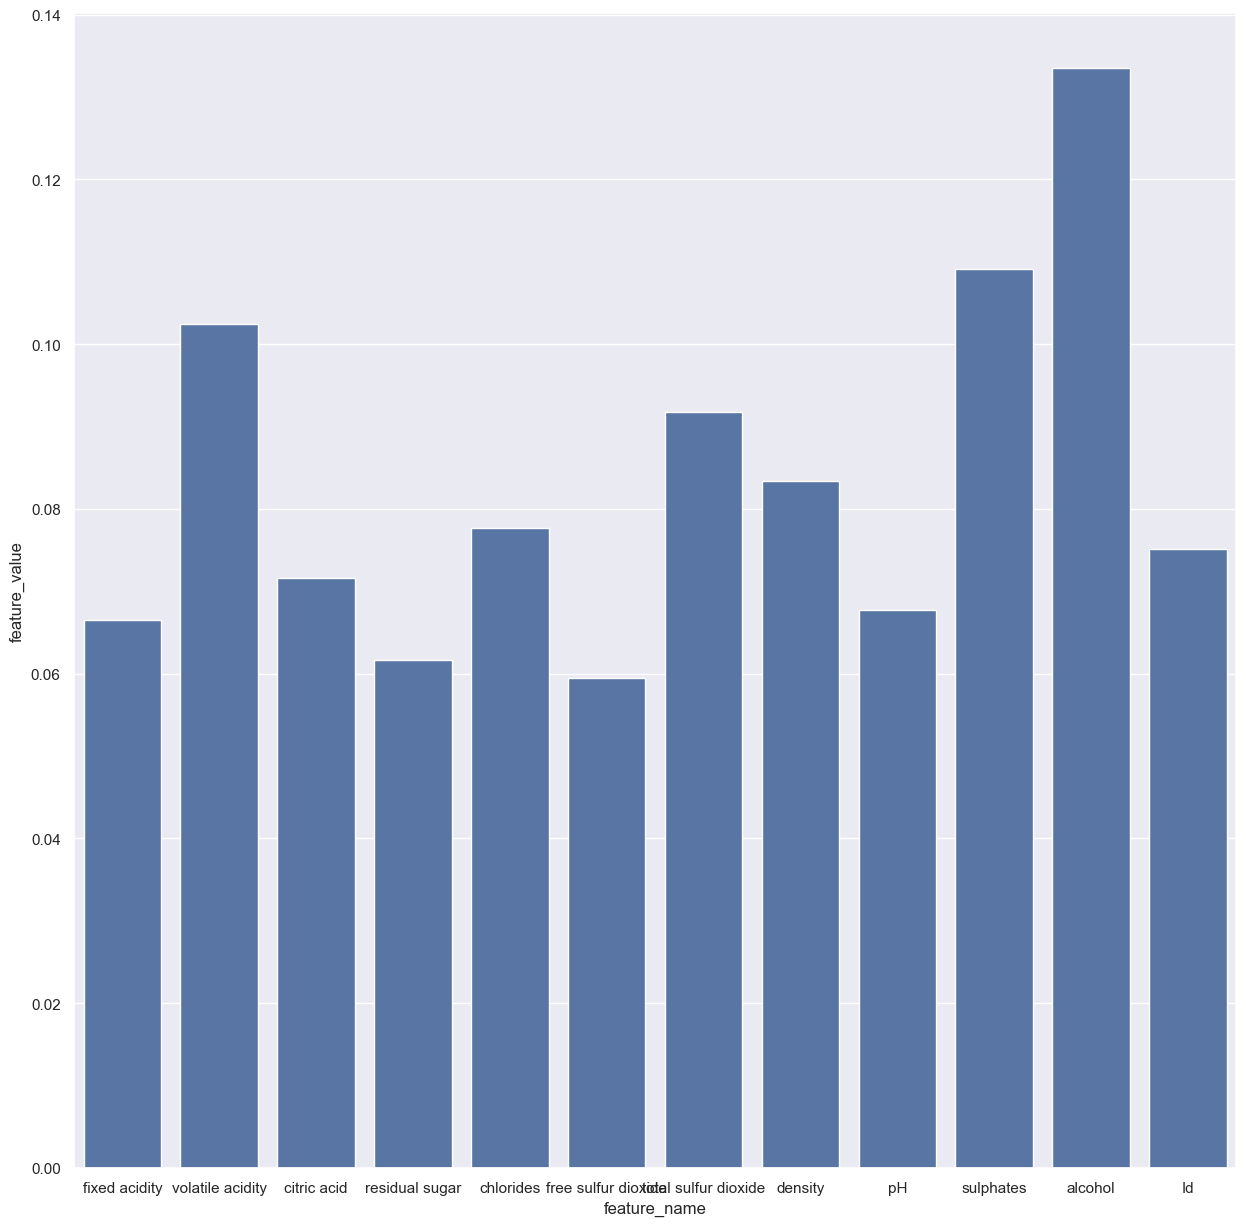

In [ ]:
important_cols = model.feature_importances_
importance = pd.DataFrame(columns=["feature_name", "feature_value"])
importance['feature_name'] = x.columns
importance['feature_value'] = important_cols

plt.figure(figsize=(15,15))
sns.barplot(x='feature_name',y='feature_value',data=importance)

## Finding Accuracy without changing hyperparameters:

In [ ]:
accuracy_score(yhat,y_test)


0.6812227074235808

In [ ]:
print(classification_report(yhat,y_test))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         0
           5       0.76      0.72      0.74       102
           6       0.68      0.65      0.66       103
           7       0.62      0.67      0.64        24
           8       0.00      0.00      0.00         0

    accuracy                           0.68       229
   macro avg       0.41      0.41      0.41       229
weighted avg       0.71      0.68      0.69       229



C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

## Changing HyperParameters


In [ ]:
from sklearn.model_selection import validation_curve
import numpy as np
n_estimators=[10,50,200,450,600,800,1000]

train_scores,test_scores = validation_curve(RandomForestClassifier(),X=x_train_smote,y=y_train_smote,param_name='n_estimators',param_range=n_estimators,cv = 3,scoring='accuracy')


Now this validation_curve returns 2 2D Arrays as we are doing cv(cross_validation 3 times). So we take the mean of those scores and we plot a straight line on the graph. 

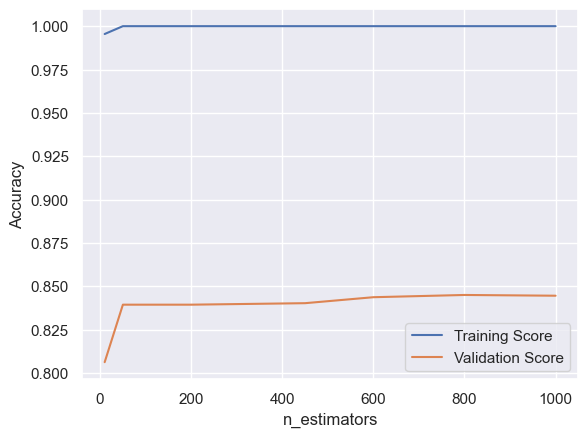

In [ ]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(n_estimators, train_mean, label="Training Score")
plt.plot(n_estimators, test_mean, label="Validation Score")

plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

 From this graph, n_estimators has to be 200

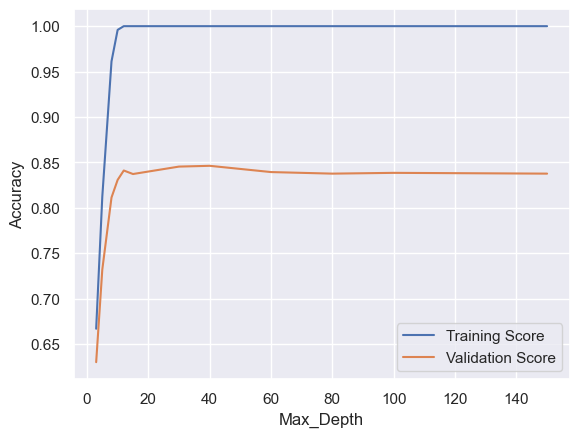

In [ ]:
max_depth = [3,5,8,10,12,15,30,40,60,80,100,150]
train_scores,test_scores = validation_curve(RandomForestClassifier(),X=x_train_smote,y=y_train_smote,param_name='max_depth',param_range=max_depth,cv = 3,scoring='accuracy')

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(max_depth, train_mean, label="Training Score")
plt.plot(max_depth, test_mean, label="Validation Score")

plt.xlabel("Max_Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


From this we can say that the max_depth should be 60

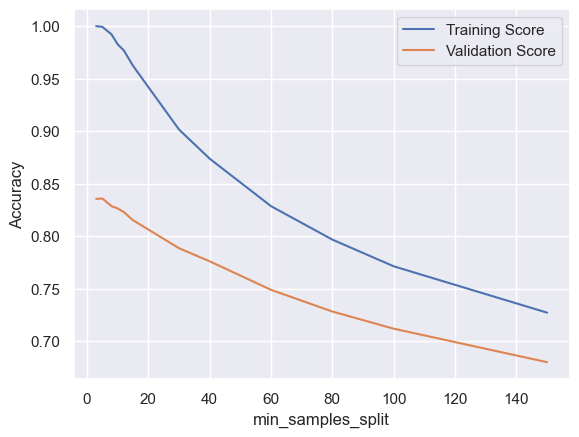

In [ ]:
min_samples_split = [3,5,8,10,12,15,30,40,60,80,100,150]
train_scores,test_scores = validation_curve(RandomForestClassifier(),X=x_train_smote,y=y_train_smote,param_name='min_samples_split',param_range=min_samples_split,cv = 3,scoring='accuracy')

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(min_samples_split, train_mean, label="Training Score")
plt.plot(min_samples_split, test_mean, label="Validation Score")

plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Instead of doing for everything, lets find the best parameters for all hyperparameters using RandomizedSearchCV

In [ ]:
param_grid={
    'n_estimators':[10,50,200,450,600,800,1000],
    'max_depth' : [3,5,8,10,12,15,30,40,60,80,100,150],
    'min_samples_split' : [1,2,3,5,8,10,12,15,30,40,60,80,100,150],
    'min_samples_leaf' : [1,2,4,5,10,20,50],
    'bootstrap':[True,False],
    'max_features':['sqrt','log2',None]
}

from sklearn.model_selection import RandomizedSearchCV

grid = RandomizedSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    n_iter=100,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train_smote,y_train_smote)
grid.best_params_

C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
30 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\U

{'n_estimators': 600,
 'min_samples_split': 3,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 80,
 'bootstrap': True}

This is the output that we got 
{'n_estimators': 800,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 40,
 'bootstrap': True}

## Calculating the Accuracy using best HyperParameters

In [ ]:
acc_model = RandomForestClassifier(n_estimators=600,
 min_samples_split=3,
 min_samples_leaf=1,
 max_features='sqrt',
 max_depth=80,
 bootstrap=True)
acc_model.fit(x_train_smote,y_train_smote)
y_pred = acc_model.predict(x_test)
accuracy_score(y_pred,y_test)


0.6244541484716157

In [ ]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         6
           5       0.72      0.71      0.72        97
           6       0.52      0.64      0.57        80
           7       0.73      0.44      0.55        43
           8       0.00      0.00      0.00         2

    accuracy                           0.61       229
   macro avg       0.33      0.30      0.31       229
weighted avg       0.62      0.61      0.61       229



C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Accuracy has decreased by 0.10 Percent and the entire report got a lil worse after using this as we can see that in the classification_report.Because we used SMOTE now we are gonna use normal data but with class_weight='balanced'

## Finding Hyperparameters

In [ ]:
param_grid={
    'n_estimators':[10,50,200,450,600,800,1000],
    'max_depth' : [3,5,8,10,12,15,30,40,60,80,100,150],
    'min_samples_split' : [1,2,3,5,8,10,12,15,30,40,60,80,100,150],
    'min_samples_leaf' : [1,2,4,5,10,20,50],
    'bootstrap':[True,False],
    'max_features':['sqrt','log2',None]
}

from sklearn.model_selection import RandomizedSearchCV

grid = RandomizedSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    n_iter=100,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train,y_train)
grid.best_params_

C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
35 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\U

{'n_estimators': 1000,
 'min_samples_split': 3,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 80,
 'bootstrap': True}

In [ ]:
acc_model = RandomForestClassifier(n_estimators=1000,
 min_samples_split=3,
 min_samples_leaf=2,
 max_features='sqrt',
 max_depth=80,
 bootstrap=True,
 class_weight = 'balanced'
)
acc_model.fit(x_train,y_train)
y_pred = acc_model.predict(x_test)
accuracy_score(y_pred,y_test)


0.6812227074235808

Here it only drops by 2%. This balancing method works very well


Without the balancing, here are the results

In [ ]:
acc_model = RandomForestClassifier(n_estimators=1000,
 min_samples_split=3,
 min_samples_leaf=2,
 max_features='sqrt',
 max_depth=80,
 bootstrap=True,
)
acc_model.fit(x_train,y_train)
y_pred = acc_model.predict(x_test)
accuracy_score(y_pred,y_test)



0.6986899563318777

This provides with 2% better results when the data is unbalanced. But still we should prefer using the model where the data is classified.

In [3]:

raw_data = pd.read_csv('WineQT.csv')
raw_data.isnull().sum()




fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

## Visualizing the Data

In [4]:
raw_data.describe(include='all')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


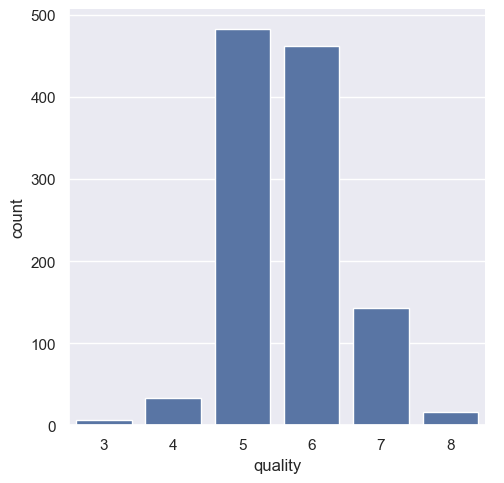

In [5]:
sns.catplot(x='quality',data=raw_data,kind='count')

<Axes: xlabel='quality', ylabel='volatile acidity'>

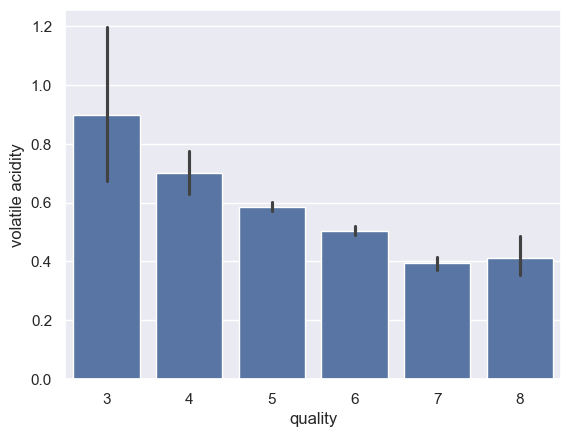

In [6]:
sns.barplot(x='quality',y='volatile acidity',data=raw_data)

From this we know that, as volatile acidity decreases, the quality increases

<Axes: xlabel='quality', ylabel='citric acid'>

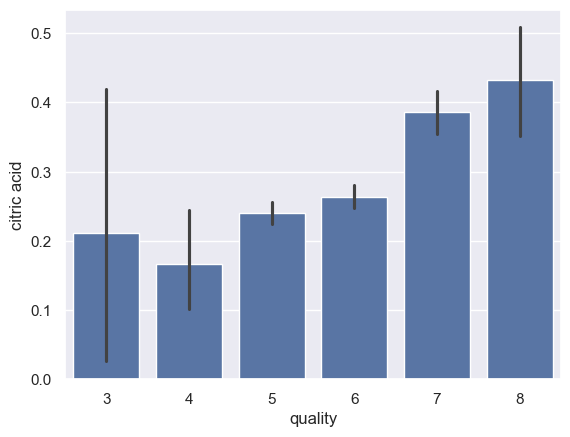

In [7]:
sns.barplot(x='quality',y='citric acid',data=raw_data)

From this we can conclude that as citric acid value increases, the quality increases


## Splitting Features

In [8]:
x = raw_data.drop(columns='quality')
y = raw_data['quality']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)



(914,)

## Balancing the Data using SMOTE:

In [62]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

## Training and Building the Model


In [46]:
model = RandomForestClassifier()
model.fit(x_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Predicting the test data


In [47]:
yhat = model.predict(x_test)



## Checking which feature matters:


<Axes: xlabel='feature_name', ylabel='feature_value'>

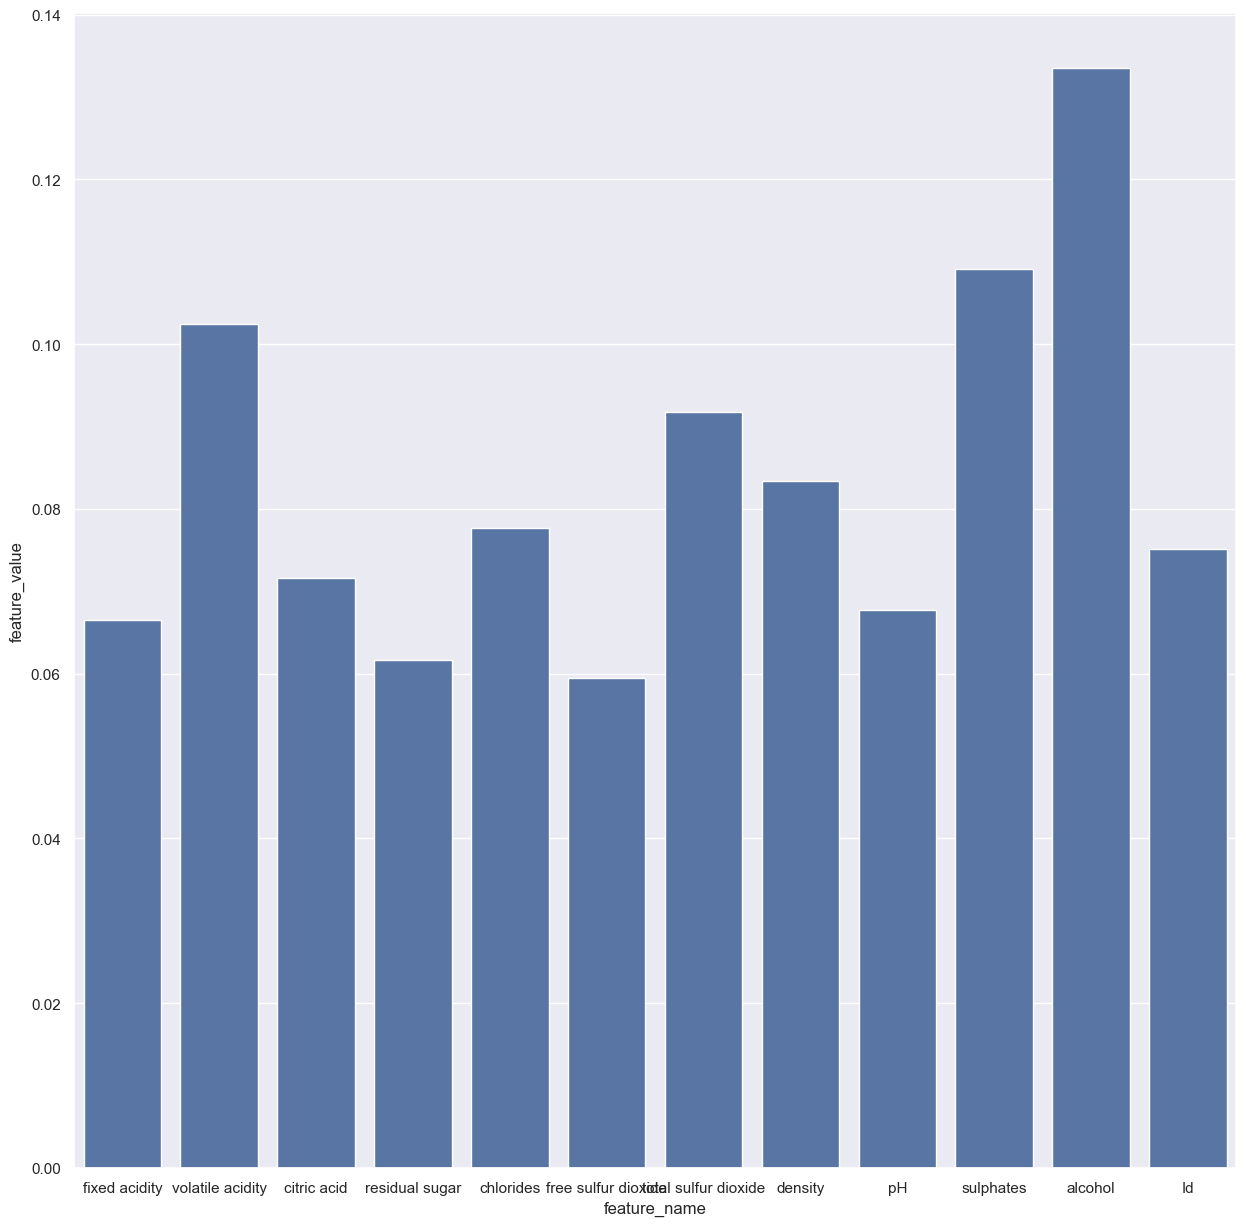

In [48]:
important_cols = model.feature_importances_
importance = pd.DataFrame(columns=["feature_name", "feature_value"])
importance['feature_name'] = x.columns
importance['feature_value'] = important_cols

plt.figure(figsize=(15,15))
sns.barplot(x='feature_name',y='feature_value',data=importance)

## Finding Accuracy without changing hyperparameters:

In [49]:
accuracy_score(yhat,y_test)


0.6812227074235808

In [51]:
print(classification_report(yhat,y_test))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         0
           5       0.76      0.72      0.74       102
           6       0.68      0.65      0.66       103
           7       0.62      0.67      0.64        24
           8       0.00      0.00      0.00         0

    accuracy                           0.68       229
   macro avg       0.41      0.41      0.41       229
weighted avg       0.71      0.68      0.69       229



C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

## Changing HyperParameters


In [72]:
from sklearn.model_selection import validation_curve
import numpy as np
n_estimators=[10,50,200,450,600,800,1000]

train_scores,test_scores = validation_curve(RandomForestClassifier(),X=x_train_smote,y=y_train_smote,param_name='n_estimators',param_range=n_estimators,cv = 3,scoring='accuracy')


Now this validation_curve returns 2 2D Arrays as we are doing cv(cross_validation 3 times). So we take the mean of those scores and we plot a straight line on the graph. 

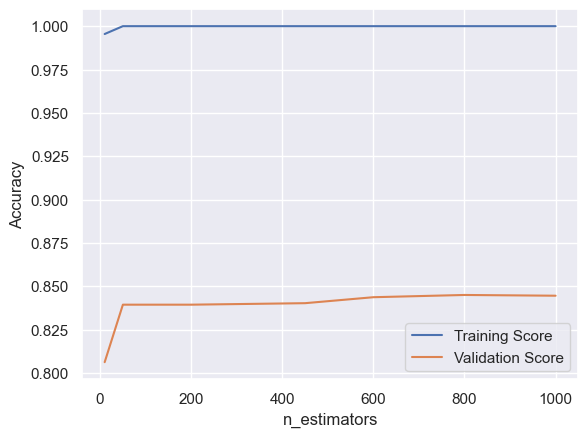

In [73]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(n_estimators, train_mean, label="Training Score")
plt.plot(n_estimators, test_mean, label="Validation Score")

plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

 From this graph, n_estimators has to be 200

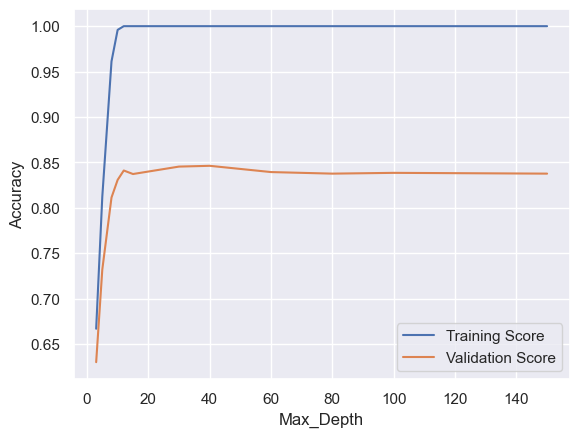

In [71]:
max_depth = [3,5,8,10,12,15,30,40,60,80,100,150]
train_scores,test_scores = validation_curve(RandomForestClassifier(),X=x_train_smote,y=y_train_smote,param_name='max_depth',param_range=max_depth,cv = 3,scoring='accuracy')

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(max_depth, train_mean, label="Training Score")
plt.plot(max_depth, test_mean, label="Validation Score")

plt.xlabel("Max_Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


From this we can say that the max_depth should be 60

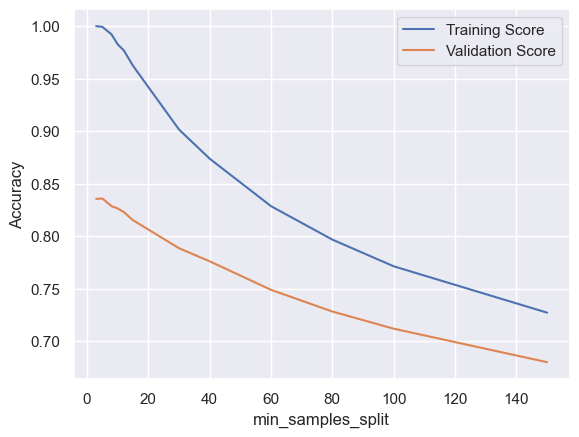

In [70]:
min_samples_split = [3,5,8,10,12,15,30,40,60,80,100,150]
train_scores,test_scores = validation_curve(RandomForestClassifier(),X=x_train_smote,y=y_train_smote,param_name='min_samples_split',param_range=min_samples_split,cv = 3,scoring='accuracy')

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(min_samples_split, train_mean, label="Training Score")
plt.plot(min_samples_split, test_mean, label="Validation Score")

plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Instead of doing for everything, lets find the best parameters for all hyperparameters using RandomizedSearchCV

In [68]:
param_grid={
    'n_estimators':[10,50,200,450,600,800,1000],
    'max_depth' : [3,5,8,10,12,15,30,40,60,80,100,150],
    'min_samples_split' : [1,2,3,5,8,10,12,15,30,40,60,80,100,150],
    'min_samples_leaf' : [1,2,4,5,10,20,50],
    'bootstrap':[True,False],
    'max_features':['sqrt','log2',None]
}

from sklearn.model_selection import RandomizedSearchCV

grid = RandomizedSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    n_iter=100,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train_smote,y_train_smote)
grid.best_params_

C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
30 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\U

{'n_estimators': 600,
 'min_samples_split': 3,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 80,
 'bootstrap': True}

This is the output that we got 
{'n_estimators': 800,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 40,
 'bootstrap': True}

## Calculating the Accuracy using best HyperParameters

In [85]:
acc_model = RandomForestClassifier(n_estimators=600,
 min_samples_split=3,
 min_samples_leaf=1,
 max_features='sqrt',
 max_depth=80,
 bootstrap=True)
acc_model.fit(x_train_smote,y_train_smote)
y_pred = acc_model.predict(x_test)
accuracy_score(y_pred,y_test)


0.6244541484716157

In [77]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         6
           5       0.72      0.71      0.72        97
           6       0.52      0.64      0.57        80
           7       0.73      0.44      0.55        43
           8       0.00      0.00      0.00         2

    accuracy                           0.61       229
   macro avg       0.33      0.30      0.31       229
weighted avg       0.62      0.61      0.61       229



C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Accuracy has decreased by 0.10 Percent and the entire report got a lil worse after using this as we can see that in the classification_report.Because we used SMOTE now we are gonna use normal data but with class_weight='balanced'

## Finding Hyperparameters

In [88]:
param_grid={
    'n_estimators':[10,50,200,450,600,800,1000],
    'max_depth' : [3,5,8,10,12,15,30,40,60,80,100,150],
    'min_samples_split' : [1,2,3,5,8,10,12,15,30,40,60,80,100,150],
    'min_samples_leaf' : [1,2,4,5,10,20,50],
    'bootstrap':[True,False],
    'max_features':['sqrt','log2',None]
}

from sklearn.model_selection import RandomizedSearchCV

grid = RandomizedSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    n_iter=100,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train,y_train)
grid.best_params_

C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
35 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\cepha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\U

{'n_estimators': 1000,
 'min_samples_split': 3,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 80,
 'bootstrap': True}

In [92]:
acc_model = RandomForestClassifier(n_estimators=1000,
 min_samples_split=3,
 min_samples_leaf=2,
 max_features='sqrt',
 max_depth=80,
 bootstrap=True,
 class_weight = 'balanced'
)
acc_model.fit(x_train,y_train)
y_pred = acc_model.predict(x_test)
accuracy_score(y_pred,y_test)


0.6812227074235808

Here it only drops by 2%. This balancing method works very well


Without the balancing, here are the results

In [98]:
acc_model = RandomForestClassifier(n_estimators=1000,
 min_samples_split=3,
 min_samples_leaf=2,
 max_features='sqrt',
 max_depth=80,
 bootstrap=True,
)
acc_model.fit(x_train,y_train)
y_pred = acc_model.predict(x_test)
accuracy_score(y_pred,y_test)



0.6986899563318777

This provides with 2% better results when the data is unbalanced. But still we should prefer using the model where the data is classified.